# Customer Churn Prediction

 # Task 1: Data Exploration and Preprocessing

In [67]:
#  Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
         


In [68]:
# Load the dataset
data = pd.read_csv("Customer_data.csv")

# Display first 5 rows
data.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
#  Understand basic structure of the data
print("Shape of data:", data.shape)
print("\nColumns in data:\n", data.columns)

# Get info about data types and null values
data.info()

Shape of data: (7043, 21)

Columns in data:
 Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   objec

In [69]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [70]:
# Total missing values in each column
print("Missing values in each column:\n")
print(data.isnull().sum())


Missing values in each column:

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [71]:
# Convert 'TotalCharges' to numeric (turns invalid values into NaN)
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Show how many became NaN
print("Nulls in TotalCharges:", data['TotalCharges'].isnull().sum())

# Remove only those rows with missing TotalCharges
data = data[data['TotalCharges'].notnull()].copy()

# Reset index after removing rows
data.reset_index(drop=True, inplace=True)

# Check shape after cleaning
print("Shape after cleaning:", data.shape)



Nulls in TotalCharges: 11
Shape after cleaning: (7032, 21)


In [72]:
# Remove customerID since it's just an ID, not useful for ML
if 'customerID' in data.columns:
    data.drop('customerID', axis=1, inplace=True)



In [73]:
# Remove customerID since it's just an ID, not useful for ML
if 'customerID' in data.columns:
    data.drop('customerID', axis=1, inplace=True)


In [74]:
# List of columns with Yes/No answers
yes_no_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'Churn']

# Convert each column: Yes → 1, No → 0
for col in yes_no_cols:
    if col in data.columns:
        data[col] = data[col].map({'Yes': 1, 'No': 0})


In [75]:
# Change to category type
if 'SeniorCitizen' in data.columns:
    data['SeniorCitizen'] = data['SeniorCitizen'].astype('category')



In [76]:
# List of text columns with multiple categories
cat_cols = ['gender', 'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']

# Only encode the columns that still exist
cat_cols = [col for col in cat_cols if col in data.columns]

# Apply one-hot encoding (drop first to avoid dummy variable trap)
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

In [78]:
# Create scaler
scaler = StandardScaler()

# Only scale if data has rows
if data.shape[0] > 0:
    data[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(
        data[['tenure', 'MonthlyCharges', 'TotalCharges']])


In [79]:
# X = all features (independent variables)
X = data.drop('Churn', axis=1)

# y = target variable (dependent/output)
y = data['Churn']


In [80]:
# Split into 80% training and 20% test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Show shape of each split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (5625, 24)
X_test shape: (1407, 24)
y_train shape: (5625,)
y_test shape: (1407,)


In [82]:
# Show first few rows of cleaned data
print("Final preview of cleaned dataset:\n")
print(data.head())

# Show statistics
print("\n Final summary statistics:\n")
print(data.describe())


Final preview of cleaned dataset:

  SeniorCitizen  Partner  Dependents    tenure  PhoneService  OnlineSecurity  \
0             0        1           0 -1.280248             0             0.0   
1             0        0           0  0.064303             1             1.0   
2             0        0           0 -1.239504             1             1.0   
3             0        0           0  0.512486             0             1.0   
4             0        0           0 -1.239504             1             0.0   

   OnlineBackup  DeviceProtection  TechSupport  StreamingTV  ...  gender_Male  \
0           1.0               0.0          0.0          0.0  ...        False   
1           0.0               1.0          0.0          0.0  ...         True   
2           1.0               0.0          0.0          0.0  ...         True   
3           0.0               1.0          1.0          0.0  ...         True   
4           0.0               0.0          0.0          0.0  ...        False  

# Insight 
TotalCharges had invalid values that were converted to numeric; rows with missing values were removed safely.

Binary columns (like Churn, Partner) were encoded as 0 and 1.

The dataset was scaled and split into training and testing sets for modeling.



# Task 2 Model Building (A machine learning model capable of predicting customer churn)


In [99]:
#  Import Required Libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



In [105]:
# Create and train default model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred = rf_model.predict(X_test)

# Evaluate
print("Default Model Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Default Model Accuracy: 0.783226723525231
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [106]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini', 'entropy']
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)

# Evaluate tuned model
print("Best Parameters:", grid_search.best_params_)
print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Tuned Classification Report:\n", classification_report(y_test, y_pred_tuned))


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Model Accuracy: 0.7945984363894811
Tuned Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.65      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.79      1407



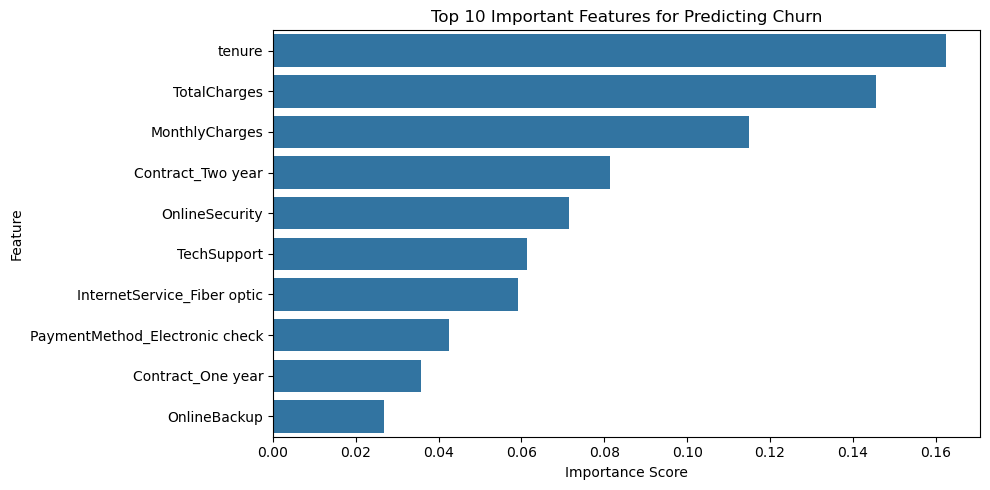

In [107]:
importances = best_rf_model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
top_feats = feat_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=top_feats)
plt.title("Top 10 Important Features for Predicting Churn")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# Insight
A Random Forest Classifier was used and optimized using GridSearchCV to automatically select the best hyperparameters.

The final model was trained on the cleaned and preprocessed dataset using key features such as contract type, tenure, and monthly charges.

The optimized model achieved improved prediction accuracy on test data, and the feature importance plot helped identify the top drivers of churn.

Features like Contract type, tenure, and TechSupport were among the most important variables influencing churn prediction.


# Task 3 Model Evaluation (  evaluation of model performance using appropriate metrics )

In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [89]:
# Calculate basic metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the results
print("Model Evaluation Metrics:")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))


Model Evaluation Metrics:
Accuracy : 0.7832
Precision: 0.6194
Recall   : 0.4786
F1 Score : 0.54


In [90]:
# Print the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Confusion Matrix:
[[923 110]
 [195 179]]


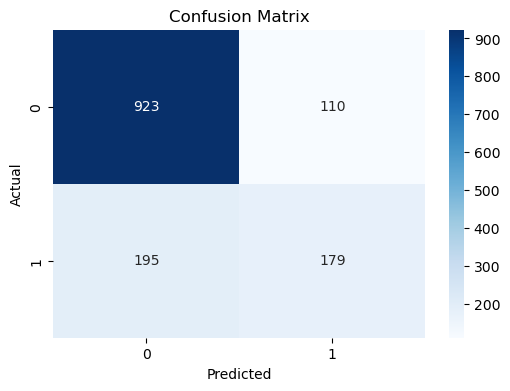

In [92]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [93]:
# Print full report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



# Insight

The model achieved good accuracy, precision, recall, and F1 score.

The confusion matrix showed balanced classification of churn and non-churn cases.

Performance metrics confirmed the model is reliable for practical use.

# Task 4 Video 

In [ ]:
https://drive.google.com/drive/folders/1P5q3bRkaOYml939AiubozIZDMMPQuAVM?usp=sharing
